## Analyzing Trends Across Neighborhoods to Identify Underlying Factors

### Leverage unsupervised learning methods to uncover hidden patterns in the 311 data and compare it with Pittsburgh’s neighborhood data. By analyzing trends across neighborhoods and incorporating additional factors such as demographics, infrastructure, and local conditions, we can identify the root causes of varying closure times and call volumes.



In [96]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import random 

import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import KMeans

### Clean neighborhood data 

https://data.wprdc.org/dataset/2020-census-redistricting-data-extracts/resource/a8414ed5-c50f-417e-bb67-82b734660da6

In [4]:
# Read in neighborhood data

neighborhoods = pd.read_csv('../Data/2020Census_Neighborhood_Dataset.csv')

In [5]:
#neighborhoods

In [6]:
# Removing columns from 2010 and that are comparisons between 2020 and 2010

to_drop = neighborhoods.columns[neighborhoods.columns.str.startswith(('2010', 'Change'))]
neighborhoods.drop(to_drop, axis=1, inplace=True)

In [7]:
#neighborhoods

In [8]:
# Sanity check = PGH population, per Google, was just under 300k in 2020

neighborhoods['2020_Total_Population'].sum()
# Outputs 302971 - okay

302971

In [9]:
# Changing Neighborhood column capitalization to make merging easier

neighborhoods = neighborhoods.rename(columns = {'Neighborhood': 'neighborhood'})

### Combine neighborhood data with existing DataFrame

Combination in Cleaned Data file, used here for exploration

In [11]:
# Read in existing data

#df = pd.read_csv('../Data/CleanedData_311_Dataset.csv')

In [12]:
# Find which neighborhoods are in existing data

#df['neighborhood'].unique()

In [13]:
# Find if all neighborhoods are present in census data

#a = df['neighborhood'].unique()
#b = neighborhoods['neighborhood'].unique()

#diff = [i for i in a if i not in b]
#diff

In [14]:
# Changes in dataset -> census data

# Central Business District -> Central Business District (Downtown)
# Spring Hill-City View -> 	Spring Hill-City
# Mount Oliver Borough -> Mt. Oliver
# Arlington -> Arlington - Arlington Heights (Combined)
# Arlington Heights -> 	Arlington - Arlington Heights (Combined)

#recode_nbhds = {'Central Business District': 'Central Business District (Downtown)', 'Spring Hill-City View': 'Spring Hill-City',
#                'Mount Oliver Borough': 'Mt. Oliver', 'Arlington': 'Arlington - Arlington Heights (Combined)',
#                'Arlington Heights': 'Arlington - Arlington Heights (Combined)'}

In [15]:
# Making changes to original DataFrame to combine neighborhood data

#df['neighborhood'] = df['neighborhood'].replace(recode_nbhds)

In [16]:
#df['neighborhood'].unique()

In [17]:
# Merging both DataFrams on neighborhood columns

#combineddf = pd.merge(df, neighborhoods, how = 'left', on = 'neighborhood')

In [18]:
#combineddf

## Clustering neighborhoods based on demographic data

### Principal Component Analysis (PCA)

In [21]:
# Changing each neighborhood's race columns to proportions of the neighborhood's population

# Applying to all columns except 'neighborhood' and '2020_Total_Population'
neighborhoods.iloc[:, 2:].astype('float64')
neighborhoods.iloc[:, 3:] = neighborhoods.iloc[:, 3:].div(neighborhoods['2020_Total_Population'], axis=0)

In [22]:
neighborhoods.head()

,_id,neighborhood,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
0,1,Allegheny Center,1419,0.942213,0.481325,0.274841,0.005638,0.165610,0.000705,0.014094,0.057787,0.035236
1,2,Allegheny West,540,0.912963,0.788889,0.059259,0.001852,0.029630,0.001852,0.031481,0.087037,0.075926
2,3,Allentown,2305,0.922343,0.551844,0.340564,0.001302,0.008243,0.002603,0.017787,0.077657,0.035141
3,4,Arlington - Arlington Heights (Combined),2040,0.925980,0.591176,0.303922,0.002451,0.005882,0.000000,0.022549,0.074020,0.033333
4,5,Banksville,4127,0.934335,0.773201,0.047008,0.001696,0.093288,0.000485,0.018658,0.065665,0.038284


In [23]:
# Scaling data for PCA/clustering

nScaled = neighborhoods.copy()
nScaled = nScaled.drop(columns = ['_id', 'neighborhood'])

nScaled[nScaled.columns] = StandardScaler().fit_transform(nScaled)
nScaled.describe()

,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
count,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01
mean,1.247442e-17,4.671045e-15,1.811909e-16,2.005262e-16,-4.677906e-17,-4.740278e-17,-1.122697e-17,2.494883e-16,-1.702758e-16,6.689406e-17
std,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00
min,-1.031140e+00,-4.373876e+00,-2.136641e+00,-9.990126e-01,-1.288272e+00,-8.238723e-01,-4.250465e-01,-1.642819e+00,-1.895413e+00,-1.392392e+00
25%,-6.896776e-01,-4.111096e-01,-6.408873e-01,-8.387532e-01,-7.806883e-01,-6.456562e-01,-4.250465e-01,-6.119654e-01,-5.640662e-01,-4.904735e-01
50%,-3.168408e-01,8.390247e-02,2.303246e-01,-2.601222e-01,-1.482078e-01,-4.230743e-01,-3.525355e-01,-1.587251e-01,-8.390247e-02,-1.400798e-01
75%,2.201783e-01,5.640662e-01,8.430200e-01,5.480243e-01,6.899168e-01,1.391037e-01,5.813893e-02,2.527526e-01,4.111096e-01,2.642919e-01
max,3.628711e+00,1.895413e+00,1.247668e+00,2.227346e+00,2.838559e+00,3.803626e+00,7.978452e+00,4.164802e+00,4.373876e+00,7.241410e+00


In [24]:
# PCA

pca = PCA(n_components = 2)
pcaResult = pca.fit(nScaled)
pcaResult

PCA(n_components=2)

In [25]:
pcaResult2 = pca.fit_transform(nScaled)

In [26]:
pca.explained_variance_ratio_

array([0.3228708 , 0.21095714])

In [27]:
# Variance explained by the two pcs - 53.38%

sum(pca.explained_variance_ratio_)

0.5338279320527024

In [28]:
pcaViz = pd.DataFrame(abs(pca.components_), columns = nScaled.columns, index = ['PC 1', 'PC 2'])
pcaViz

,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
PC 1,0.116470,0.431616,0.385216,0.439273,0.179906,0.242226,0.142593,0.110799,0.431616,0.385810
PC 2,0.350244,0.382926,0.387036,0.358152,0.339127,0.217129,0.271690,0.192034,0.382926,0.182073


### Elbow Method to Find K-Means Hyperparameters

In [30]:
# Finding inertia of dataset

inertias = []

for k in range(1, 20):
  kmeans = KMeans(n_clusters = k, random_state = 7362)
  kmeans.fit(nScaled)
  inertias.append(kmeans.inertia_)
    
inertias

[890.0,
 697.6853281773961,
 605.2205949172882,
 511.9003865976092,
 429.6436602479686,
 371.1214650569285,
 340.77395095989345,
 315.5539798722913,
 303.5242243946901,
 278.70348821783443,
 251.7319321691608,
 240.44941754377226,
 222.5405312420589,
 208.1177076894582,
 195.33003931759083,
 185.71743602578786,
 179.010744342085,
 170.13430356140282,
 158.90408039080302]

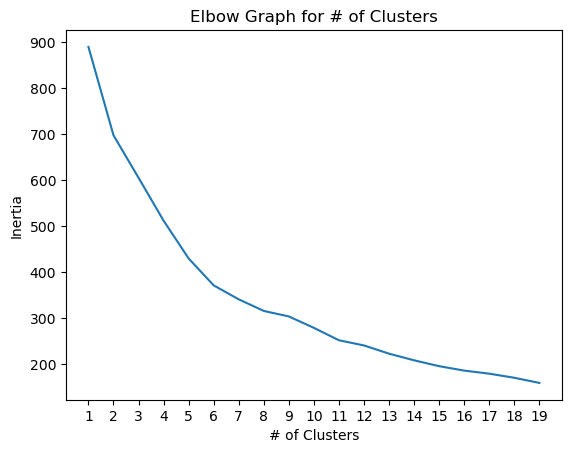

In [31]:
# Plotting elbow graph - 7 clusters

plt.xticks(range(1, 20))
plt.plot(range(1, 20), inertias)

plt.xlabel('# of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Graph for # of Clusters')

plt.show()

In [32]:
numClusters = 8

### K-Means Clustering

In [34]:
# Getting cluster labels

kmeans = KMeans(n_clusters = numClusters, random_state = 7362)
kmeans_model = kmeans.fit(nScaled)

kmeans_model.labels_

array([4, 5, 1, 1, 4, 0, 5, 5, 4, 0, 1, 1, 4, 0, 4, 4, 1, 1, 4, 0, 2, 1,
       0, 1, 1, 5, 0, 4, 1, 5, 4, 1, 5, 0, 0, 4, 1, 1, 4, 0, 0, 0, 5, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 3, 1, 0, 4, 1, 1, 0, 1, 4, 1, 1, 1,
       7, 5, 4, 1, 4, 1, 1, 1, 7, 7, 1, 1, 4, 1, 1, 0, 1, 0, 1, 6, 3, 4,
       1])

In [35]:
neighborhoods['label'] = kmeans_model.labels_
neighborhoods

,_id,neighborhood,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population,label
0,1,Allegheny Center,1419,0.942213,0.481325,0.274841,0.005638,0.165610,0.000705,0.014094,0.057787,0.035236,4
1,2,Allegheny West,540,0.912963,0.788889,0.059259,0.001852,0.029630,0.001852,0.031481,0.087037,0.075926,5
2,3,Allentown,2305,0.922343,0.551844,0.340564,0.001302,0.008243,0.002603,0.017787,0.077657,0.035141,1
3,4,Arlington - Arlington Heights (Combined),2040,0.925980,0.591176,0.303922,0.002451,0.005882,0.000000,0.022549,0.074020,0.033333,1
4,5,Banksville,4127,0.934335,0.773201,0.047008,0.001696,0.093288,0.000485,0.018658,0.065665,0.038284,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,85,Upper Lawrenceville,2394,0.946533,0.842941,0.064327,0.002089,0.030911,0.000000,0.006266,0.053467,0.027569,1
85,86,West End,205,0.878049,0.575610,0.243902,0.004878,0.029268,0.009756,0.014634,0.121951,0.053659,6
86,87,West Oakland,2534,0.968824,0.604578,0.239937,0.002368,0.077743,0.000789,0.043410,0.031176,0.044199,3
87,88,Westwood,3332,0.944478,0.659064,0.083433,0.000900,0.177671,0.000600,0.022809,0.055522,0.036615,4


In [36]:
# Finding cluster centroids

centroids = kmeans_model.cluster_centers_
centroids

array([[-3.63253019e-01,  8.96088350e-01, -1.53370686e+00,
         1.59828016e+00,  7.16708289e-01, -5.58263274e-01,
        -1.47632260e-01, -2.16293242e-01, -8.96088350e-01,
        -5.33314717e-01],
       [-2.73851378e-01,  7.51664230e-03,  5.58699089e-01,
        -4.05611875e-01, -4.57759202e-01, -4.91078533e-01,
        -4.29815348e-02, -4.49317678e-01, -7.51664230e-03,
        -2.48123528e-01],
       [-1.03114011e+00, -4.37387572e+00,  2.30324573e-01,
        -7.15993441e-01, -1.28827199e+00,  1.21020330e+00,
        -4.25046523e-01, -1.64281881e+00,  4.37387572e+00,
         7.24141047e+00],
       [ 9.77274606e-01,  1.30252358e+00,  2.39454087e-01,
        -5.00056475e-01,  4.01256177e-01,  1.59285517e+00,
        -8.51260004e-02,  2.29898395e+00, -1.30252358e+00,
         3.87656763e-02],
       [ 5.51266246e-01, -7.29126124e-02,  4.23114052e-01,
        -5.95956415e-01, -8.75961728e-02,  1.04555184e+00,
        -1.01885748e-01,  1.23574367e-01,  7.29126124e-02,
         2.

In [37]:
pcaCentroids = pca.transform(centroids)

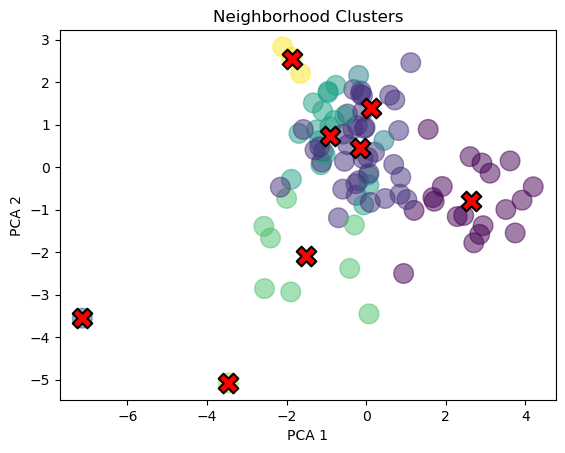

In [38]:
# Visualizing with PCA

plt.scatter(pcaResult2[:, 0], pcaResult2[:, 1], c = kmeans_model.labels_, alpha = 0.5, s = 200)
plt.title('Neighborhood Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.scatter(pcaCentroids[:, 0], pcaCentroids[:, 1], marker = 'X', s = 200, linewidths = 1.5,
            color = 'red', edgecolors = "black")

plt.show()

In [39]:
# Finding silhouette score: ~0.2246

print("Silhouette_score: ", metrics.silhouette_score(nScaled, kmeans_model.labels_))

Silhouette_score:  0.2245893332537209


In [40]:
nbhoodlist = list(neighborhoods[neighborhoods['label'] == 0]['neighborhood'])
nbhoodlist

['Bedford Dwellings',
 'Bluff',
 'California-Kirkbride',
 'Chartiers City',
 'Crawford-Roberts',
 'East Hills',
 'Garfield',
 'Glen Hazel',
 'Homewood North',
 'Homewood South',
 'Homewood West',
 'Larimer',
 'Lincoln-Lemington-Belmar',
 'Manchester',
 'Middle Hill',
 'Northview Heights',
 'Perry South',
 'Terrace Village',
 'Upper Hill']

In [41]:
# Function to print neighborhoods in each cluster

def clusterAssignment(num):
    '''
    takes cluster number and returns neighborhoods in that cluster

    clusterAssignment(1) -> 'Greenfield, ...'
    '''

    nbhoodlist = list(neighborhoods[neighborhoods['label'] == num]['neighborhood'])

    nbhoodstring = ''

    for n in range(0, len(nbhoodlist) - 1):
        n = str(nbhoodlist[n])
        nbhoodstring = nbhoodstring + n + ', '

    nbhoodstring = nbhoodstring + nbhoodlist[len(nbhoodlist) - 1]

    string = 'The neighborhood(s) in cluster {} are: {}'.format(num, nbhoodstring)

    return string
    

for c in range(0, numClusters):
    print(clusterAssignment(c), '\n')

The neighborhood(s) in cluster 0 are: Bedford Dwellings, Bluff, California-Kirkbride, Chartiers City, Crawford-Roberts, East Hills, Garfield, Glen Hazel, Homewood North, Homewood South, Homewood West, Larimer, Lincoln-Lemington-Belmar, Manchester, Middle Hill, Northview Heights, Perry South, Terrace Village, Upper Hill 

The neighborhood(s) in cluster 1 are: Allentown, Arlington - Arlington Heights (Combined), Bon Air, Brighton Heights, Central Lawrenceville, Central Northside, Crafton Heights, Duquesne Heights, East Allegheny, Elliott, Fineview, Hays, Hazelwood, Lincoln Place, Lower Lawrenceville, Marshall-Shadeland, Morningside, Mount Washington, Mt. Oliver, New Homestead, North Shore, Overbrook, Perry North, Point Breeze, Polish Hill, Regent Square, Ridgemont, South Shore, South Side Slopes, Spring Garden, Spring Hill-City, St. Clair, Stanton Heights, Summer Hill, Swisshelm Park, Troy Hill, Upper Lawrenceville, Windgap 

The neighborhood(s) in cluster 2 are: Chateau 

The neighborho

## Clustering neighborhoods based on request types

In [43]:
# Read in cleaned data (not one-hot encoded) and group based on cluster

df = pd.read_csv('../Data/IntermediateCleanedData_311_Dataset.csv')

In [44]:
df.sample(10)

,_id,group_id,num_requests,parent_closed,status_name,status_code,create_date_et,last_action_et,closed_date_et,origin,...,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
157033,574746,644789,1,t,closed,1,2022-06-13 14:59:00,2022-06-27 13:07:00,2022-06-27 13:07:00,Call Center,...,13063,0.940136,0.833116,0.061931,0.002373,0.027099,0.000536,0.015081,0.059864,0.035597
256250,701399,701715,1,t,closed,1,2022-12-28 09:38:00,2023-03-16 10:36:00,2023-03-16 10:36:00,Control Panel,...,7261,0.928385,0.801129,0.043658,0.001515,0.062939,0.000964,0.018179,0.071615,0.045861
357791,810263,921753,1,t,closed,1,2025-01-21 12:27:00,2025-01-27 22:02:00,2025-01-27 22:02:00,Call Center,...,2293,0.948539,0.129525,0.772351,0.003925,0.028783,0.000436,0.013519,0.051461,0.023986
29688,69628,745733,4,f,in progress,3,2023-06-07 17:32:00,2023-06-08 14:14:00,NaN,Report2Gov iOS,...,4046,0.929066,0.423875,0.475037,0.002719,0.014088,0.000741,0.012605,0.070934,0.024221
297387,745497,689661,1,t,closed,1,2022-10-28 21:19:00,2023-01-12 15:05:00,2023-01-12 15:05:00,Website,...,10290,0.933916,0.687658,0.161905,0.002818,0.061516,0.000194,0.019825,0.066084,0.039164
74889,226837,522824,1,t,closed,1,2021-05-12 14:32:00,2021-05-14 15:04:00,2021-05-14 15:04:00,Website,...,1419,0.942213,0.481325,0.274841,0.005638,0.165610,0.000705,0.014094,0.057787,0.035236
183780,624829,732937,1,t,closed,1,2023-05-03 11:25:00,2023-05-12 14:52:00,2023-05-12 14:52:00,Call Center,...,1757,0.971542,0.048378,0.912920,0.000000,0.002846,0.000000,0.007399,0.028458,0.013090
175497,616005,744018,1,t,closed,1,2023-06-04 11:08:00,2023-06-07 06:41:00,2023-06-07 06:41:00,Website,...,1419,0.942213,0.481325,0.274841,0.005638,0.165610,0.000705,0.014094,0.057787,0.035236
252727,697678,741673,1,t,closed,1,2023-05-29 17:06:00,2023-06-14 14:03:00,2023-06-14 14:03:00,Call Center,...,5835,0.948757,0.777549,0.049357,0.001028,0.107455,0.000171,0.013196,0.051243,0.037532
27472,67315,760050,1,f,open,0,2023-07-19 08:22:00,2023-07-19 08:22:00,NaN,Call Center,...,4327,0.934135,0.791079,0.102380,0.000231,0.017795,0.001618,0.021031,0.065865,0.046915


In [45]:
# Add column to cleaned_data for neighborhood cluster number

nbhClusters = pd.DataFrame(neighborhoods[['neighborhood', 'label']])

combineddf = pd.merge(df, nbhClusters, how = 'left', on = 'neighborhood')
combineddf.sample(10)

,_id,group_id,num_requests,parent_closed,status_name,status_code,create_date_et,last_action_et,closed_date_et,origin,...,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population,label
347321,798312,909693,1,t,closed,1,2024-12-11 22:24:00,2024-12-19 08:02:00,2024-12-19 08:02:00,Website,...,0.943773,0.669995,0.232265,0.001576,0.022070,0.001051,0.016816,0.056227,0.038360,1
267974,713957,863730,1,t,closed,1,2024-07-09 10:29:00,2024-09-04 15:16:00,2024-09-04 15:16:00,Control Panel,...,0.939978,0.763027,0.031400,0.001094,0.128209,0.000084,0.016163,0.060022,0.050509,7
61579,165121,659050,1,t,closed,1,2022-07-25 11:56:00,2022-08-03 09:07:00,2022-08-03 09:07:00,Twitter,...,0.934135,0.791079,0.102380,0.000231,0.017795,0.001618,0.021031,0.065865,0.046915,1
255929,701050,753692,1,t,closed,1,2023-07-03 07:04:00,2023-08-04 09:27:00,2023-08-04 09:27:00,Report2Gov iOS,...,0.948757,0.777549,0.049357,0.001028,0.107455,0.000171,0.013196,0.051243,0.037532,4
342228,792485,904195,1,t,closed,1,2024-11-18 15:27:00,2024-11-21 07:01:00,2024-11-21 07:01:00,Website,...,0.935416,0.573445,0.173025,0.003905,0.169420,0.000300,0.015320,0.064584,0.054371,4
104172,351941,627935,1,t,closed,1,2022-04-28 13:13:00,2022-04-30 13:12:00,2022-04-30 13:12:00,Call Center,...,0.923336,0.833583,0.034779,0.000748,0.045625,0.000561,0.008040,0.076664,0.037771,1
163456,602244,835023,1,t,closed,1,2024-04-10 14:32:00,2024-04-11 13:26:00,2024-04-11 13:26:00,Report2Gov Website,...,0.936862,0.769376,0.124764,0.001134,0.029490,0.000000,0.012098,0.063138,0.037807,1
331673,780786,701997,1,t,closed,1,2022-12-29 10:05:00,2022-12-30 05:52:00,2022-12-30 05:52:00,Call Center,...,0.943054,0.814351,0.104822,0.002296,0.010333,0.001263,0.009989,0.056946,0.030540,1
66607,189476,574028,1,t,closed,1,2021-10-14 15:20:00,2021-10-22 11:19:00,2021-10-22 11:19:00,Call Center,...,0.946533,0.842941,0.064327,0.002089,0.030911,0.000000,0.006266,0.053467,0.027569,1
19045,58505,880816,1,f,open,0,2024-08-28 15:27:00,2024-08-28 15:27:00,NaN,Website,...,0.942213,0.481325,0.274841,0.005638,0.165610,0.000705,0.014094,0.057787,0.035236,4


In [46]:
combineddf.columns

Index(['_id', 'group_id', 'num_requests', 'parent_closed', 'status_name',
       'status_code', 'create_date_et', 'last_action_et', 'closed_date_et',
       'origin', 'city', 'neighborhood', 'council_district', 'ward',
       'police_zone', 'geo_accuracy', 'category', 'dept_simplified',
       '2020_Total_Population', '2020_OneRace_Population',
       '2020_White_Alone_Population', '2020_Black_Alone_Population',
       '2020_American_Indian_and_Alaska_Native_alone_population',
       '2020_Asian_Alone_Population',
       '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio',
       '2020_Any_other_single_race_alone_Popualtion',
       '2020_Population_two_or_more_races',
       '2020_Hispanic_or_Latino_Population', 'label'],
      dtype='object')

In [100]:
combineddf['closed_date_et'] = pd.to_datetime(combineddf['closed_date_et'])
combineddf['create_date_et'] = pd.to_datetime(combineddf['create_date_et'])

combineddf['close_time'] = combineddf['closed_date_et'] - combineddf['create_date_et']
combineddf.sample(10)

,_id,group_id,num_requests,parent_closed,status_name,status_code,create_date_et,last_action_et,closed_date_et,origin,...,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population,label,close_time
182709,623684,801748,1,t,closed,1,2023-12-07 16:22:00,2023-12-07 16:31:00,2023-12-07 16:31:00,Website,...,0.610847,0.322509,0.006120,0.020741,0.000000,0.015981,0.023801,0.056273,0,0 days 00:09:00
148357,538664,593216,1,t,closed,1,2022-01-07 22:35:00,2022-01-12 13:15:00,2022-01-12 13:15:00,Website,...,0.647631,0.267343,0.001269,0.006345,0.000000,0.018190,0.059222,0.027496,1,4 days 14:40:00
78203,241350,581439,1,t,closed,1,2021-11-16 08:02:00,2021-11-16 13:26:00,2021-11-16 13:26:00,Call Center,...,0.816421,0.097171,0.002153,0.015990,0.000000,0.009840,0.058426,0.030135,1,0 days 05:24:00
223065,665958,769798,1,t,closed,1,2023-08-15 15:27:00,2023-08-21 07:09:00,2023-08-21 07:09:00,Call Center,...,0.283931,0.635325,0.003453,0.004250,0.000531,0.025232,0.047278,0.034529,0,5 days 15:42:00
110588,379530,647253,1,t,closed,1,2022-06-21 11:47:00,2022-06-21 12:04:00,2022-06-21 12:04:00,Call Center,...,0.097085,0.846810,0.001650,0.006051,0.000000,0.013476,0.034928,0.017602,0,0 days 00:17:00
118726,415189,549605,1,t,closed,1,2021-08-02 12:41:00,2021-08-02 13:43:00,2021-08-02 13:43:00,Call Center,...,0.029204,0.895133,0.004425,0.004867,0.000000,0.012389,0.053982,0.018142,0,0 days 01:02:00
212284,654763,644479,1,t,closed,1,2022-06-13 10:54:00,2022-12-01 18:02:00,2022-12-01 18:02:00,Call Center,...,0.551844,0.340564,0.001302,0.008243,0.002603,0.017787,0.077657,0.035141,1,171 days 07:08:00
55681,138582,507977,1,t,closed,1,2021-03-16 13:28:00,2021-03-26 06:16:00,2021-03-26 06:16:00,Website,...,0.769376,0.124764,0.001134,0.029490,0.000000,0.012098,0.063138,0.037807,1,9 days 16:48:00
308568,757054,873808,1,t,closed,1,2024-08-07 08:44:00,2024-08-08 14:02:00,2024-08-08 14:02:00,Call Center,...,0.826704,0.052230,0.000536,0.048480,0.000134,0.014330,0.057587,0.040311,4,1 days 05:18:00
346305,797131,908611,1,f,in progress,3,2024-12-09 08:54:00,2025-01-29 13:02:00,NaT,Call Center,...,0.826704,0.052230,0.000536,0.048480,0.000134,0.014330,0.057587,0.040311,4,NaT


In [124]:
# Showing all df values to compare neighborhoods

pd.set_option('display.max_rows', None)

In [133]:
# Number of requests by neighborhood

combineddf.groupby(['neighborhood'])['category'].count()

neighborhood
Allegheny Center                             2074
Allegheny West                                875
Allentown                                    3520
Arlington - Arlington Heights (Combined)     3089
Banksville                                   2358
Bedford Dwellings                             826
Beechview                                    8527
Beltzhoover                                  3184
Bloomfield                                  11279
Bluff                                        2384
Bon Air                                       989
Brighton Heights                             7287
Brookline                                   14767
California-Kirkbride                         1177
Carrick                                     13772
Central Business District (Downtown)        13025
Central Lawrenceville                        6146
Central Northside                            5109
Central Oakland                              5876
Chartiers City                       

In [135]:
# Number of requests by cluster

combineddf.groupby(['label'])['category'].count()

label
0     47153
1    139419
2       964
3      5820
4    113134
5     25957
6       789
7     29623
Name: category, dtype: int64

In [137]:
# Average closure time for each cluster

combineddf.groupby(['label'])['close_time'].mean()

label
0   49 days 21:47:42.725560515
1   41 days 21:03:20.055008974
2   36 days 11:25:24.232081911
3   71 days 09:55:54.576899321
4   42 days 16:21:51.641772658
5   44 days 20:50:28.243225023
6   38 days 12:08:04.055172414
7   61 days 13:07:00.571766096
Name: close_time, dtype: timedelta64[ns]

In [139]:
# Types of reports for each cluster, most to least

combineddf.groupby(['label'])['category'].value_counts()

label  category                                       
0      Road/Street Issues                                  8736
       Neighborhood Issues                                 6985
       Missed Refuse Pick Up                               3822
       Parking                                             2833
       Missed Recycling Pick Up                            2305
       Building Maintenance                                2105
       Animal Issues                                       1675
       Garbage and Litter Issues                           1648
       Litter, Public Property                             1629
       In database, but not on 311 Web Submission Form     1540
       City Owned Property Maintenance                     1363
       Public Safety                                       1326
       Street Light                                        1295
       Tree Issues                                         1141
       Utility Issues                            